# Model 1b: FO permeate flux (short-term, real end-of-pipe wastewater, dataset A)

Replicates Fig. 3A: flux decline as water recovery increases + cartridge-filter
replacement recovery jump at ~107 min / 85-90% recovery.
Enriches the 11 flux points with an interpolated water-recovery / feed-conductivity
trajectory derived from the Sample analysis sheet (recovery % <-> conductivity anchor points).

In [1]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
flux = pd.read_csv("data/fo_flux_shortterm.csv")
sample = pd.read_csv("data/sample_analysis.csv")

In [3]:
# anchor recovery% -> time based on paper Fig 3A annotations & closest matching flux timestamps
anchor_recovery_time = {25:30.46, 50:59.47, 75:72.0, 80:91.49, 85:101.49, 90:115.50}
feedin = sample[sample.stream=="Feed in"].set_index("recovery_pct")
anchor_t = np.array(sorted(anchor_recovery_time.values()))
anchor_r = np.array([k for k,v in sorted(anchor_recovery_time.items(), key=lambda x:x[1])])
anchor_cond = feedin.loc[anchor_r, "conductivity_uS_cm"].values
anchor_toc = feedin.loc[anchor_r, "TOC_mg_L"].values

In [4]:
flux["recovery_pct"] = np.interp(flux.time_min, anchor_t, anchor_r)
flux["feed_cond_uScm"] = np.interp(flux.time_min, anchor_t, anchor_cond)
flux["feed_toc"] = np.interp(flux.time_min, anchor_t, anchor_toc)

In [5]:
X = flux[["time_min","recovery_pct","feed_cond_uScm"]].values
y = flux["Jw"].values

In [6]:
loo = LeaveOneOut()
model = GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.08, random_state=0)
pred_loo = cross_val_predict(model, X, y, cv=loo)
r2 = r2_score(y, pred_loo)
rmse = mean_squared_error(y, pred_loo)**0.5
print(f"LOOCV R2={r2:.3f} RMSE={rmse:.3f}")

LOOCV R2=0.425 RMSE=1.133


In [7]:
model.fit(X, y)
# dense time grid for smooth curve
t_grid = np.linspace(flux.time_min.min(), flux.time_min.max(), 200)
r_grid = np.interp(t_grid, anchor_t, anchor_r)
c_grid = np.interp(t_grid, anchor_t, anchor_cond)
Xg = np.column_stack([t_grid, r_grid, c_grid])
yg = model.predict(Xg)

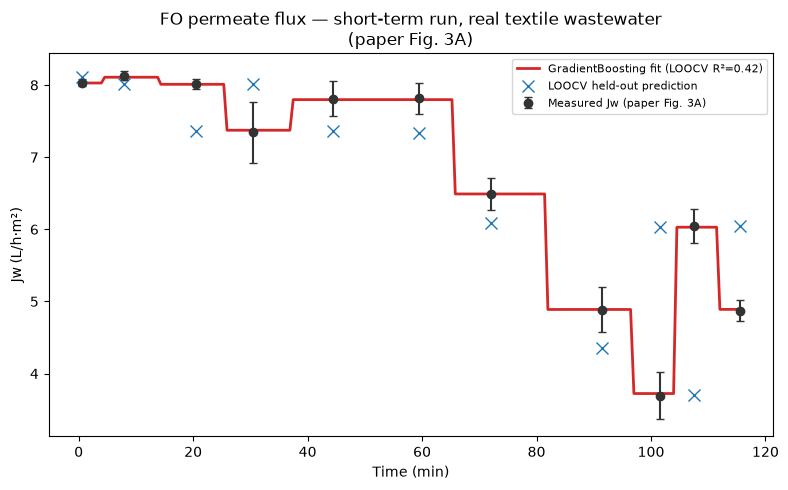

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(flux.time_min, flux.Jw, yerr=flux.SD, fmt="o", color="#333", capsize=3, label="Measured Jw (paper Fig. 3A)")
ax.plot(t_grid, yg, "-", color="#d62728", lw=2, label="GradientBoosting fit (LOOCV R²={:.2f})".format(r2))
ax.plot(flux.time_min, pred_loo, "x", color="#1f77b4", ms=8, label="LOOCV held-out prediction")
ax.set_xlabel("Time (min)"); ax.set_ylabel("Jw (L/h·m²)")
ax.set_title("FO permeate flux — short-term run, real textile wastewater\n(paper Fig. 3A)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("plots/model1b_fo_flux_shortterm.png", dpi=150)
plt.show()

In [9]:
flux.to_csv("data/fo_flux_shortterm_enriched.csv", index=False)
with open("models/metrics_fo_flux_shortterm.txt","w") as f:
    f.write(f"LOOCV R2={r2:.3f} RMSE={rmse:.3f}\n")
    f.write("Note: only 11 data points; recovery% and feed conductivity are interpolated from\n")
    f.write("paper-figure recovery annotations matched against Sample analysis sheet, not directly logged per-timestamp.\n")
print("done")

done
